In [2]:
import os, glob, json
import cv2
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

In [23]:

DATASET_ROOT = "/kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset/Real Life Violence Dataset"
VIOLENCE_DIR = os.path.join(DATASET_ROOT, "Violence")
NONVIOLENCE_DIR = os.path.join(DATASET_ROOT, "NonViolence")

In [24]:
IMG_SIZE = 224
SEQUENCE_LENGTH = 20          # frames sampled per video (evenly spaced)
OUTPUT_DIR = "/kaggle/working/features"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VIDEO_EXTS = ("*.mp4", "*.avi", "*.mov", "*.mkv")

In [25]:

def list_videos(folder):
    files = []
    for ext in VIDEO_EXTS:
        files.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(files)

In [26]:
def sample_frame_indices(total_frames, n_samples):
    if total_frames <= 0:
        return np.zeros(n_samples, dtype=int)
    if total_frames < n_samples:
        idx = np.arange(total_frames)
        idx = np.pad(idx, (0, n_samples - total_frames), mode="edge")
        return idx
    return np.linspace(0, total_frames - 1, n_samples).astype(int)

In [27]:
def read_frames(video_path, n_samples=SEQUENCE_LENGTH, img_size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = sample_frame_indices(total, n_samples)
    idx_set = set(idxs.tolist())
    max_idx = int(max(idxs)) if len(idxs) else 0

    frame_cache = {}
    current = 0
    while current <= max_idx:
        ok, frame = cap.read()
        if not ok:
            break
        if current in idx_set:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frame_cache[current] = frame
        current += 1
    cap.release()

    frames = []
    for i in idxs:
        if i in frame_cache:
            frames.append(frame_cache[i])
        elif frame_cache:
            frames.append(list(frame_cache.values())[-1])
        else:
            frames.append(np.zeros((img_size, img_size, 3), dtype=np.uint8))

    while len(frames) < n_samples:
        frames.append(frames[-1] if frames else np.zeros((img_size, img_size, 3), dtype=np.uint8))

    return np.array(frames[:n_samples], dtype=np.uint8)


In [28]:
def build_feature_extractor():
    base = MobileNetV2(weights="imagenet", include_top=False, pooling="avg",
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    return base

In [29]:
def extract_video_features(video_path, extractor):
    frames = read_frames(video_path)
    x = preprocess_input(frames.astype(np.float32))
    feats = extractor.predict(x, batch_size=SEQUENCE_LENGTH, verbose=0)  # (SEQ_LEN, 1280)
    return feats

In [30]:
def main():
    violence_videos = list_videos(VIOLENCE_DIR)
    nonviolence_videos = list_videos(NONVIOLENCE_DIR)
    print(f"Violence videos: {len(violence_videos)}")
    print(f"NonViolence videos: {len(nonviolence_videos)}")

    all_videos = [(p, 1) for p in violence_videos] + [(p, 0) for p in nonviolence_videos]
    extractor = build_feature_extractor()

    X = np.zeros((len(all_videos), SEQUENCE_LENGTH, 1280), dtype=np.float32)
    y = np.zeros((len(all_videos),), dtype=np.int32)

    for i, (path, label) in enumerate(tqdm(all_videos, desc="Extracting features")):
        try:
            X[i] = extract_video_features(path, extractor)
            y[i] = label
        except Exception as e:
            print(f"Failed on {path}: {e}")

    np.save(os.path.join(OUTPUT_DIR, "X.npy"), X)
    np.save(os.path.join(OUTPUT_DIR, "y.npy"), y)

    config = {"img_size": IMG_SIZE, "sequence_length": SEQUENCE_LENGTH, "feature_dim": 1280}
    with open(os.path.join(OUTPUT_DIR, "config.json"), "w") as f:
        json.dump(config, f, indent=2)

    print("Saved features to", OUTPUT_DIR)


In [31]:
if __name__ == "__main__":
    main()

Violence videos: 1000
NonViolence videos: 1000


Extracting features:   0%|          | 0/2000 [00:00<?, ?it/s]2026-07-06 04:40:04.504245: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 04:40:04.640806: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1783312806.053748     179 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Extracting features:  65%|██████▍   | 1294/2000 [06:29<10:07,  1.16it/s] [h264 @ 0x264385c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x264385c0] error while decoding MB 98 31
Extracting features: 100%|██████████| 2000/2000 [08:36<00:00,  3.87it/s]

Saved features to /kaggle/working/features


In [32]:
# 2nd 


['config.json', 'y.npy', 'X.npy']


In [33]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [34]:
FEATURES_DIR = "/kaggle/working/features"
MODEL_OUT = "/kaggle/working/violence_lstm_model.keras"

In [35]:
with open(os.path.join(FEATURES_DIR, "config.json")) as f:
    CONFIG = json.load(f)

In [36]:
SEQUENCE_LENGTH = CONFIG["sequence_length"]
FEATURE_DIM = CONFIG["feature_dim"]

In [37]:
X = np.load(os.path.join(FEATURES_DIR, "X.npy"))
y = np.load(os.path.join(FEATURES_DIR, "y.npy"))

In [38]:
# 70 / 15 / 15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (1400, 20, 1280), Val: (300, 20, 1280), Test: (300, 20, 1280)


In [40]:
def build_model():
    inp = layers.Input(shape=(SEQUENCE_LENGTH, FEATURE_DIM))
    x = layers.Masking(mask_value=0.0)(inp)
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.5)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

In [41]:
model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 20, 1280)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 20, 1280)  │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 20, 1280)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 20)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 20, 128)   │    721,408 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 20, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 775,041 (2.96 MB)

 Trainable params: 775,041 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
cbs = [
    callbacks.ModelCheckpoint(MODEL_OUT, monitor="val_auc", mode="max", save_best_only=True),
    callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=12, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
]

In [43]:

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=16,
    callbacks=cbs,
    verbose=1,
)

Epoch 1/80
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7214 - auc: 0.8112 - loss: 0.5901 - val_accuracy: 0.8733 - val_auc: 0.9455 - val_loss: 0.4021 - learning_rate: 1.0000e-04
Epoch 2/80
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9007 - auc: 0.9570 - loss: 0.3289 - val_accuracy: 0.9233 - val_auc: 0.9720 - val_loss: 0.2216 - learning_rate: 1.0000e-04
Epoch 3/80
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9500 - auc: 0.9805 - loss: 0.1821 - val_accuracy: 0.9467 - val_auc: 0.9887 - val_loss: 0.1540 - learning_rate: 1.0000e-04
Epoch 4/80
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9650 - auc: 0.9912 - loss: 0.1177 - val_accuracy: 0.9367 - val_auc: 0.9889 - val_loss: 0.1604 - learning_rate: 1.0000e-04
Epoch 5/80
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9743 - auc: 0.9947 - loss: 0.0863 - val_accuracy: 0.9667 - val_auc: 0.9910 - val_loss: 0.1281 - learning_rate: 1.0000e-04
Epoch 6/80
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.

In [44]:
# ---------------- Evaluate ----------------
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=["NonViolence", "Violence"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
              precision    recall  f1-score   support

 NonViolence       0.99      0.95      0.97       150
    Violence       0.95      0.99      0.97       150

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

Confusion matrix:
 [[143   7]
 [  2 148]]


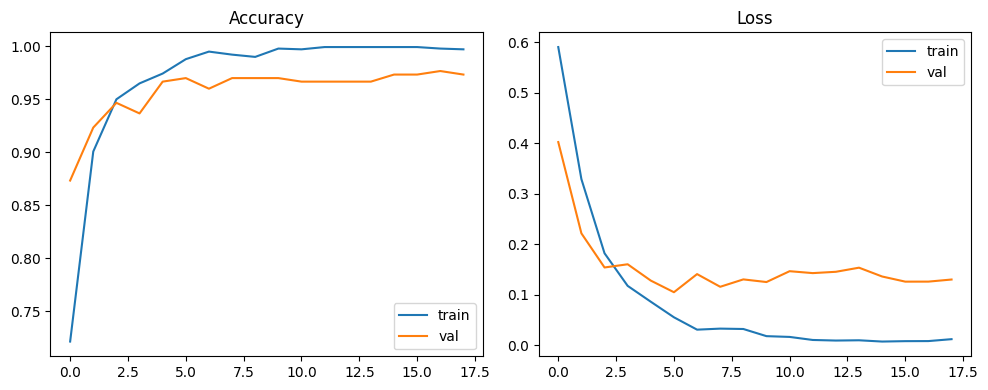

In [45]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/training_history.png")

In [46]:
model.save(MODEL_OUT)
print("Saved model to", MODEL_OUT)

Saved model to /kaggle/working/violence_lstm_model.keras
